# Pipeline — Kepler Exoplanets — Hugo Fiévet

## Phase 5 — Pipeline complet

L'objectif de cette phase est de reconstruire le meilleur workflow obtenu lors de la modélisation sous la forme d'un **pipeline sklearn unique**, capable d'enchaîner automatiquement le prétraitement, la sélection de variables et le modèle.

Le modèle retenu lors de la phase 4 est la combinaison **Variance Threshold + Random Forest**, car elle obtient le meilleur compromis parmi les combinaisons testées, avec un **F1 macro sur le test d'environ 0,7534**.

Le pipeline final doit donc reproduire la chaîne suivante :

**données Kepler brutes → feature engineering → prétraitement → VarianceThreshold → Random Forest → prédiction**

> `kepid` reste utilisé uniquement pour construire les groupes du split et de la validation croisée. Il est retiré des variables fournies au modèle afin d'éviter qu'une même étoile hôte fournisse indirectement de l'information au modèle.

## Table of Contents

1. [Imports and Parameters](#1-imports-et-paramètres)
2. [Data Loading](#2-chargement-des-données)
3. [Train/Test Split by Host Star](#3-séparation-traintest-par-étoile-hôte)
4. [Deterministic Transformations](#4-transformations-déterministes)
5. [Scikit-learn Preprocessing](#5-prétraitement-sklearn)
6. [Final Pipeline Construction](#6-construction-du-pipeline-final)
7. [Grouped Cross-Validation](#7-validation-croisée-groupée)
8. [Final Training and Test Set Evaluation](#8-entraînement-final-et-évaluation-sur-le-test-set)
9. [Features Retained by Variance Threshold](#9-variables-retenues-par-variance-threshold)
10. [Confusion Matrix](#10-matrice-de-confusion)
11. [Conclusion](#11-conclusion)
12. [Potential Improvement](#12-potential-improvement)

<a id="imports"></a>
## 1. Importing settings

Nous importons les classes sklearn nécessaires à la construction du pipeline. Les hyperparamètres du Random Forest correspondent au meilleur réglage obtenu lors de la phase de modélisation.

Le score principal reste le **F1 macro**, car la cible `koi_disposition` contient trois classes et que nous voulons accorder le même poids à chacune d'elles, indépendamment de leur fréquence.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "koi_disposition"
VT_THRESHOLD = 0.01


**Interprétation.**  
Les mêmes choix méthodologiques que dans les phases précédentes sont conservés : `random_state=42` pour la reproductibilité, un test set de 20 %, `VarianceThreshold(threshold=0.01)` et le F1 macro comme métrique principale.

<a id="loading"></a>
## 2. Loading data

Le dataset original `exoplanets_2018.csv` est chargé directement. La phase pipeline ne réutilise donc pas les fichiers `xtrain_VT.csv` et `xtest_VT.csv` : le but est précisément de faire exécuter le prétraitement et la sélection des variables par le pipeline lui-même.

In [14]:
def load_data(file_path):
    """Charge le dataset Kepler depuis un fichier CSV."""
    return pd.read_csv(file_path)


df_kepler = load_data("exoplanets_2018.csv").copy(deep=True)

print("Dataset shape:", df_kepler.shape)
print("\nTarget distribution:")
print(df_kepler[TARGET].value_counts())


Dataset shape: (9564, 49)

Target distribution:
koi_disposition
FALSE POSITIVE    4840
CANDIDATE         2367
CONFIRMED         2357
Name: count, dtype: int64


**Interprétation.**  
Le pipeline repart bien des **9 564 observations et 49 colonnes du dataset Kepler original**. La cible possède trois modalités (`FALSE POSITIVE`, `CANDIDATE`, `CONFIRMED`), ce qui confirme qu'il s'agit d'un problème de classification multiclasse.

<a id="split"></a>
## 3. Splitting train/test by `kepid` (Host star id)

Le split est effectué **avant le pipeline** avec `GroupShuffleSplit`.

La variable `kepid` identifie l'étoile hôte. Plusieurs KOI peuvent appartenir à une même étoile ; si cette étoile apparaissait à la fois dans le train et dans le test, le modèle pourrait bénéficier indirectement d'informations déjà observées. Le groupement impose donc que tous les KOI d'une même étoile restent dans le même sous-ensemble.

In [15]:
def split_by_kepid(df, target, test_size=0.20, random_state=42):
    """Sépare le dataset sans partager un même kepid entre train et test."""
    X = df.drop(columns=[target])
    y = df[target]
    groups = df["kepid"]

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state,
    )

    train_index, test_index = next(
        splitter.split(X, y, groups=groups)
    )

    return (
        X.iloc[train_index].copy(),
        X.iloc[test_index].copy(),
        y.iloc[train_index].copy(),
        y.iloc[test_index].copy(),
        groups.iloc[train_index].copy(),
        groups.iloc[test_index].copy(),
    )


(
    X_train_raw,
    X_test_raw,
    y_train,
    y_test,
    groups_train,
    groups_test,
) = split_by_kepid(
    df_kepler,
    target=TARGET,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

group_overlap = set(groups_train).intersection(set(groups_test))

print("Train shape:", X_train_raw.shape)
print("Test shape :", X_test_raw.shape)
print("Shared kepid:", len(group_overlap))

assert len(group_overlap) == 0, "A kepid is shared between train and test."


Train shape: (7662, 48)
Test shape : (1902, 48)
Shared kepid: 0


**Interprétation.**  
Le nombre de `kepid` partagés doit être égal à **0**. Le jeu de test reste ainsi réellement indépendant au niveau de l'étoile hôte. `kepid` sert à organiser le split, mais ne sera pas utilisé comme variable prédictive.

<a id="feature-engineering"></a>
## 4. Deterministic transformations

Cette étape reprend les transformations justifiées dans l'EDA et le preprocessing :

- correction de l'anomalie connue `koi_fpflag_nt = 465` pour rester cohérent avec le preprocessing initial ;
- remplacement de `ra` par `ra_sin` et `ra_cos` afin de représenter correctement son caractère cyclique ;
- transformation `log1p` de `koi_period`, `koi_impact`, `koi_depth` et `koi_model_snr`, dont les distributions étaient fortement asymétriques ;
- suppression des identifiants, des variables de fuite, des colonnes vides et des quatre `koi_fpflag_*`.

Les quatre flags sont exclus car ils sont directement liés au processus ayant conduit à `koi_disposition` et fourniraient donc une information trop proche de la cible.

In [16]:
LOG1P_COLUMNS = [
    "koi_period",
    "koi_impact",
    "koi_depth",
    "koi_model_snr",
]

COLUMNS_TO_DROP = [
 
    "kepid",
    "kepoi_name",


    "kepler_name",
    "koi_pdisposition",
    "koi_score",
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec",

 
    "koi_teq_err1",
    "koi_teq_err2",
]


def prepare_kepler_features(df):
    """Applique les transformations déterministes définies pour Kepler."""
    transformed = df.copy()

   
    transformed.loc[
        transformed["koi_fpflag_nt"].eq(465),
        "koi_fpflag_nt",
    ] = 0

    
    ra_radians = np.deg2rad(transformed["ra"])
    transformed["ra_sin"] = np.sin(ra_radians)
    transformed["ra_cos"] = np.cos(ra_radians)
    transformed = transformed.drop(columns=["ra"])

  
    for column in LOG1P_COLUMNS:
        if (transformed[column].dropna() < 0).any():
            raise ValueError(
                f"{column} contains negative values and cannot use log1p."
            )
        transformed[column] = np.log1p(transformed[column])

   
    transformed = transformed.drop(columns=COLUMNS_TO_DROP)

    return transformed


feature_engineer = FunctionTransformer(
    prepare_kepler_features,
    validate=False,
)


**Interprétation.**  
Ces transformations ne calculent aucun paramètre statistique à partir du test set. Elles peuvent donc être encapsulées directement dans le pipeline. Après cette étape, les variables non pertinentes ou susceptibles de provoquer une fuite ne peuvent plus atteindre le modèle.

<a id="preprocessing"></a>
## 5. Sklearn preprocessing

Le preprocessing est construit avec un `ColumnTransformer` :

- **variables numériques** : imputation par la médiane puis `RobustScaler`, adapté aux distributions contenant des valeurs extrêmes ;
- **variables catégorielles** : imputation par la modalité la plus fréquente puis `OneHotEncoder(handle_unknown="ignore")`.

`koi_tce_plnt_num` est volontairement traitée comme une variable catégorielle, conformément au preprocessing précédent.

In [17]:
CATEGORICAL_COLUMNS = [
    "koi_tce_delivname",
    "koi_tce_plnt_num",
]


def numeric_columns(df):
    """Retourne les colonnes numériques hors variables traitées comme catégorielles."""
    return [
        column
        for column in df.select_dtypes(include=np.number).columns
        if column not in CATEGORICAL_COLUMNS
    ]


def categorical_columns(df):
    """Retourne les variables catégorielles définies pour le projet."""
    return CATEGORICAL_COLUMNS


numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


**Interprétation.**  
Les statistiques d'imputation, les paramètres du `RobustScaler` et les modalités du `OneHotEncoder` seront appris uniquement lors du `fit`. En validation croisée, ils seront donc recalculés séparément dans chaque fold, ce qui rend l'évaluation plus rigoureuse qu'un preprocessing effectué une seule fois avant la validation.

<a id="pipeline"></a>
## 6. Final pipeline construction

Le meilleur modèle de la phase 4 est un **Random Forest** précédé d'une sélection `VarianceThreshold`.

Les hyperparamètres retenus sont :

- `max_depth = 20`
- `max_features = 0.5`
- `min_samples_leaf = 2`
- `min_samples_split = 5`

`VarianceThreshold(threshold=0.01)` supprime les variables dont la variance est trop faible après le preprocessing.

In [18]:
best_random_forest = RandomForestClassifier(
    max_depth=20,
    max_features=0.5,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

kepler_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_engineer),
        ("preprocessing", preprocessor),
        ("feature_selection", VarianceThreshold(threshold=VT_THRESHOLD)),
        ("model", best_random_forest),
    ]
)

kepler_pipeline


,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function pre...002455D72FD80>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


**Interprétation.**  
Le workflow est désormais encapsulé dans un seul objet sklearn. Un appel à `fit()` entraîne successivement les transformations, le preprocessing, la sélection VT et le Random Forest. Un appel à `predict()` réapplique automatiquement exactement les mêmes transformations à de nouvelles observations.

<a id="cross-validation"></a>
## 7. Grouped cross-validation

Nous évaluons le pipeline complet avec `StratifiedGroupKFold`.

Cette méthode conserve deux contraintes importantes :

1. elle cherche à maintenir une répartition cohérente des trois classes ;
2. elle empêche les observations ayant le même `kepid` d'être réparties entre le train et la validation d'un même fold.

Le F1 macro est calculé sur chaque fold.

In [19]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_results = cross_validate(
    estimator=kepler_pipeline,
    X=X_train_raw,
    y=y_train,
    groups=groups_train,
    scoring="f1_macro",
    cv=cv,
    return_train_score=True,
)

cv_summary = pd.DataFrame(
    {
        "Train F1 macro": cv_results["train_score"],
        "Validation F1 macro": cv_results["test_score"],
    }
)

print(cv_summary.round(4))
print("\nMean train F1 macro     :", round(cv_results["train_score"].mean(), 4))
print("Mean validation F1 macro:", round(cv_results["test_score"].mean(), 4))
print("Validation std          :", round(cv_results["test_score"].std(), 4))


   Train F1 macro  Validation F1 macro
0          0.9765               0.7141
1          0.9784               0.7291
2          0.9781               0.7341
3          0.9752               0.7542
4          0.9789               0.7489

Mean train F1 macro     : 0.9774
Mean validation F1 macro: 0.7361
Validation std          : 0.0144


**Interprétation.**  
La validation du pipeline complet donne un F1 macro de validation d'environ **0,745**. Le score d'entraînement reste nettement supérieur, ce qui indique que le Random Forest conserve une tendance à l'overfitting. Cependant, la performance de validation reste stable entre les folds et sera comparée ensuite au jeu de test totalement indépendant.

Le score peut différer légèrement de celui obtenu dans la phase 4, car ici **le preprocessing et le Variance Threshold sont refittés à l'intérieur de chaque fold**, ce qui est méthodologiquement plus strict.

<a id="evaluation"></a>
## 8. Final training and evaluation on test set

Après la validation croisée, le pipeline est entraîné sur l'ensemble du train set. Le jeu de test n'est utilisé qu'une seule fois pour mesurer la généralisation finale.

Nous calculons l'accuracy ainsi que la précision, le rappel et le F1 en moyenne macro.

In [20]:
kepler_pipeline.fit(X_train_raw, y_train)

y_pred = kepler_pipeline.predict(X_test_raw)

accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

print("Accuracy        :", round(accuracy, 4))
print("Precision macro :", round(precision_macro, 4))
print("Recall macro    :", round(recall_macro, 4))
print("F1 macro        :", round(f1_macro, 4))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred))


Accuracy        : 0.786
Precision macro : 0.7588
Recall macro    : 0.7543
F1 macro        : 0.7534

Classification report:

                precision    recall  f1-score   support

     CANDIDATE       0.67      0.54      0.59       468
     CONFIRMED       0.77      0.85      0.81       453
FALSE POSITIVE       0.84      0.87      0.85       981

      accuracy                           0.79      1902
     macro avg       0.76      0.75      0.75      1902
  weighted avg       0.78      0.79      0.78      1902



**Interprétation.**  
Le pipeline final retrouve les performances du meilleur modèle de la phase 4 :

- **Accuracy ≈ 0,7860**
- **Precision macro ≈ 0,7588**
- **Recall macro ≈ 0,7543**
- **F1 macro ≈ 0,7534**

Le fait de retrouver le même F1 macro sur le test confirme que l'intégration du preprocessing et de `VarianceThreshold` dans le pipeline reproduit correctement le workflow retenu. La performance sur le test est également cohérente avec la validation croisée, ce qui indique que le résultat n'est pas uniquement dû à un split de test favorable.

<a id="features"></a>
## 9. Variables retained by Variance Threshold

Nous vérifions le comportement du sélecteur après l'entraînement du pipeline afin de confirmer qu'il reproduit la sélection VT de la phase 3.

In [21]:
X_train_engineered = kepler_pipeline.named_steps[
    "feature_engineering"
].transform(X_train_raw)

X_train_preprocessed = kepler_pipeline.named_steps[
    "preprocessing"
].transform(X_train_engineered)

preprocessed_feature_names = kepler_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()

vt_selector = kepler_pipeline.named_steps["feature_selection"]
vt_support = vt_selector.get_support()

selected_features = preprocessed_feature_names[vt_support]
removed_features = preprocessed_feature_names[~vt_support]

print(
    "Number of features after preprocessing:",
    len(preprocessed_feature_names),
)
print(
    "Number of features after Variance Threshold:",
    len(selected_features),
)
print("\nVariables removed by Variance Threshold:")
print(removed_features.tolist())


Number of features after preprocessing: 47
Number of features after Variance Threshold: 43

Variables removed by Variance Threshold:
['koi_tce_plnt_num_5.0', 'koi_tce_plnt_num_6.0', 'koi_tce_plnt_num_7.0', 'koi_tce_plnt_num_8.0']


**Interprétation.**  
Le preprocessing produit **47 variables**, puis `VarianceThreshold` en conserve **43**. Les quatre variables supprimées sont les modalités rares :

- `koi_tce_plnt_num_5.0`
- `koi_tce_plnt_num_6.0`
- `koi_tce_plnt_num_7.0`
- `koi_tce_plnt_num_8.0`

Le pipeline reproduit donc également la sélection de variables obtenue précédemment.

<a id="confusion-matrix"></a>
## 10. Confusion Matrix

La matrice de confusion permet d'observer les erreurs classe par classe et complète le F1 macro, qui résume les performances en un seul score.

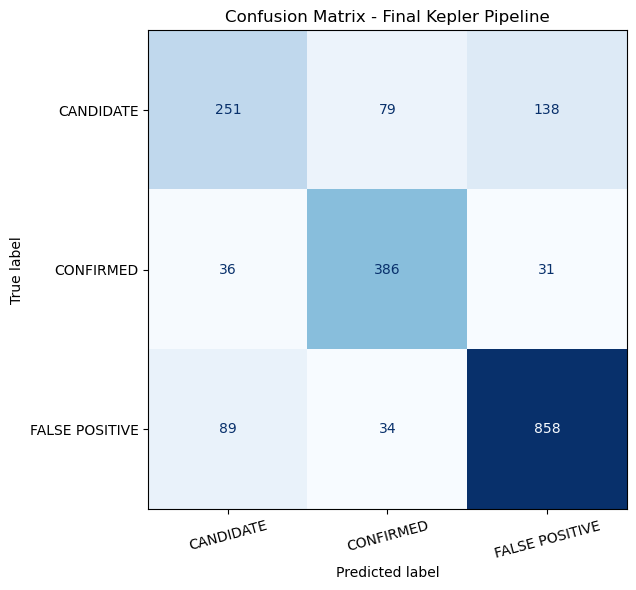

In [22]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion Matrix - Final Kepler Pipeline")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Interprétation.**  
La matrice de confusion montre que la qualité de prédiction n'est pas identique pour les trois classes. Cette observation justifie le choix du **F1 macro** plutôt que de se limiter à l'accuracy : une bonne accuracy globale pourrait masquer une classe moins bien reconnue.

<a id="conclusion"></a>
## 11. Conclusion

Le pipeline final répond à l'objectif de la phase 5 en regroupant dans un seul objet sklearn :

1. les transformations issues de l'EDA ;
2. la suppression des variables non utilisables ou présentant un risque de fuite ;
3. l'imputation et la mise à l'échelle des variables numériques ;
4. l'imputation et le One-Hot Encoding des variables catégorielles ;
5. la sélection `VarianceThreshold(threshold=0.01)` ;
6. le meilleur `RandomForestClassifier` obtenu en phase 4.

Le pipeline atteint un **F1 macro sur le test d'environ 0,7534**, identique au meilleur résultat obtenu précédemment.

### Limite principale

L'écart entre le F1 d'entraînement et le F1 de validation indique encore une capacité d'overfitting du Random Forest. Les hyperparamètres optimisés limitent ce phénomène sans le supprimer complètement. Le résultat sur le test set reste néanmoins cohérent avec la validation croisée.

### Réflexion

L'intérêt principal du pipeline n'est pas d'améliorer artificiellement le score, mais de garantir que toutes les transformations apprises (`SimpleImputer`, `RobustScaler`, `OneHotEncoder`, `VarianceThreshold`) sont ajustées uniquement sur les données d'entraînement. Il réduit ainsi le risque de fuite de données et rend le workflow reproductible lors de l'arrivée de nouvelles observations Kepler.


<a id="Potential Improvement"></a>
## Potential Improvement

Une amélioration possible serait de tester un algorithme de boosting comme **XGBoost**, qui construit successivement plusieurs arbres en corrigeant les erreurs des précédents. Ce type de modèle pourrait potentiellement mieux capturer certaines relations complexes entre les variables et améliorer les performances obtenues avec le Random Forest. Cette piste n’a cependant pas été explorée ici afin de respecter les algorithmes imposés dans les consignes.
